### Notebook 05 — Price Trend Forecasting
#### Linear Regression Model

**Model:** Linear Regression (scikit-learn)

**Forecast horizons:**
- 30 days  — tactical trading view (~6 weeks)
- 90 days  — quarterly planning view
- 180 days — semi-annual strategic view

**Validation approach:**
Time-series chronological split (80/20).
~1,000 training days (Jan 2020 to ~mid 2024).
~250 test days (approximately 1 full year of out-of-sample data).

In [1]:
# CELL 2 — Imports

import os
import sys
import warnings
import sqlite3
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))

from config.settings import (
    DB_PATH, MODEL_PATH, PROCESSED_DATA_PATH, LOG_PATH,
    LOOKBACK_DAYS, TRAIN_SPLIT_RATIO,
    FORECAST_HORIZON_SHORT,
    FORECAST_HORIZON_MEDIUM,
    FORECAST_HORIZON_LONG
)

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(f"../{LOG_PATH}", mode="a"),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger("ml_forecast")

# Dark theme
plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor":  "#161b22",
    "axes.edgecolor":   "#30363d", "text.color":       "#c9d1d9",
    "xtick.color":      "#8b949e", "ytick.color":      "#8b949e",
    "grid.color":       "#21262d", "axes.labelcolor":  "#c9d1d9",
    "axes.titlecolor":  "#e6edf3", "figure.dpi":       130,
})

# Load daily data
conn     = sqlite3.connect(f"../{DB_PATH}")
daily_df = pd.read_sql(
    "SELECT * FROM fact_daily ORDER BY ticker, date",
    conn, parse_dates=["date"]
)
conn.close()

print(f"✓ Data loaded: {daily_df.shape}")
print(f"✓ Tickers: {sorted(daily_df['ticker'].unique())}")

✓ Data loaded: (19272, 34)
✓ Tickers: ['AAPL', 'AMZN', 'BAC', 'CVX', 'GOOGL', 'GS', 'JNJ', 'JPM', 'MSFT', 'PFE', 'WMT', 'XOM']


In [2]:
# CELL 3 — Create ML Features

# Target variable: close price N days into the future

def create_ml_features(df, horizon_days):
    """
    Builds feature matrix X and target vector y for one ticker.

    Parameters
    ----------
    df           : pd.DataFrame — data for a single ticker
    horizon_days : int          — days ahead to predict

    Returns
    -------
    X            : pd.DataFrame — feature matrix
    y            : pd.Series    — target prices
    dates        : pd.Series    — corresponding dates
    feature_cols : list         — feature column names
    """
    df = df.sort_values('date').copy()
    f = pd.DataFrame(index=df.index)

    # ── Price features ────────────────────────────────────────
    # Current price and return
    f["close"]          = df["close_price"]
    f["daily_return"]   = df["daily_return"]

    # Lagged returns — what happened N days ago
    for lag in [1,3,5,10,20]:
        f[f'return_lag_{lag}d'] = df['daily_return'].shift(lag)

    # Rolling mean returns — momentum at different windows
    for window in [5, 10, 20, 60]:
        f[f'return_roll_{window}d'] = (
            df['daily_return'].rolling(window).mean()
        )

    # ── Technical indicator features ──────────────────────────
    f["rsi_14"]   = df["rsi_14"]
    f["ma_20"]    = df["ma_20"]
    f["ma_50"]    = df["ma_50"]
    f["ma_200"]   = df["ma_200"]

    # Price position relative to MAs (normalized)
    f["price_vs_ma20"]  = ((df["close_price"] - df["ma_20"]) / df["ma_20"])
    f["price_vs_ma50"]  = ((df["close_price"] - df["ma_50"]) / df["ma_50"])
    f["price_vs_ma200"] = ((df["close_price"] - df["ma_200"]) / df["ma_200"])

    # Bollinger Band position
    bb_range = (df["bb_upper"] - df["bb_lower"]).replace(0, np.nan)
    f["bb_pct"] = (df["close_price"] - df["bb_lower"]) / bb_range

    # ── Volatility features ───────────────────────────────────
    f["vol_30d"]   = df["volatility_30d"]
    f["vol_ann"]   = df["volatility_ann"]

    # ── Volume features ───────────────────────────────────────
    # Volume relative to 20-day average (buying pressure)
    vol_ma = df['volume'].rolling(20).mean()
    f['vol_ratio'] = df['volume'] / vol_ma.replace(0, np.nan)

    # ── Trend flags ───────────────────────────────────────────
    f["above_ma50"]   = df["above_ma50"].astype(float)
    f["above_ma200"]  = df["above_ma200"].astype(float)
    f["golden_cross"] = df["golden_cross"].astype(float)

    # ── Calendar features ─────────────────────────────────────
    f["month"]   = df["month"].astype(float)
    f["quarter"] = df["quarter"].astype(float)

    # ── Target: price N days forward ─────────────────────────
    # shift(-N) moves future values back — each row's target
    # is what the price will be N trading days from that row
    f["target"] = df["close_price"].shift(-horizon_days)

    f["date"] = df["date"].values

    # Drop NaN rows created by rolling windows and the target shift
    f = f.dropna()

    feature_cols = [c for c in f.columns if c not in ["target", "date", "close"]]

    X     = f[feature_cols]
    y     = f["target"]
    dates = f["date"]

    return X, y, dates, feature_cols

 #Test on AAPL
test_X, test_y, test_dates, feat_names = create_ml_features(
    daily_df[daily_df["ticker"] == "AAPL"],
    horizon_days=30
)
print(f"Feature count   : {len(feat_names)}")
print(f"Dataset size    : {test_X.shape}")
print(f"Target range    : ${test_y.min():.2f} to ${test_y.max():.2f}")
print(f"\nFeatures:\n{feat_names}")

Feature count   : 26
Dataset size    : (1516, 26)
Target range    : $74.47 to $308.82

Features:
['daily_return', 'return_lag_1d', 'return_lag_3d', 'return_lag_5d', 'return_lag_10d', 'return_lag_20d', 'return_roll_5d', 'return_roll_10d', 'return_roll_20d', 'return_roll_60d', 'rsi_14', 'ma_20', 'ma_50', 'ma_200', 'price_vs_ma20', 'price_vs_ma50', 'price_vs_ma200', 'bb_pct', 'vol_30d', 'vol_ann', 'vol_ratio', 'above_ma50', 'above_ma200', 'golden_cross', 'month', 'quarter']


In [5]:
# CELL 4 — Training and Evaluation Function

def train_and_evaluate(ticker, horizon_days, daily_df):
    """
    Full ML pipeline for one ticker and one horizon.

    Returns dict with model, scaler, predictions, and metrics.
    """

    logger.info(f'Training: {ticker} | {horizon_days}-day horizon')
    ticker_data = daily_df[daily_df['ticker'] == ticker].copy()

    X, y, dates, feature_cols = create_ml_features(ticker_data, horizon_days)
    
    # ── Chronological train/test split ────────────────────────
    split = int(len(X) * TRAIN_SPLIT_RATIO)

    X_train = X.iloc[:split]
    X_test  = X.iloc[split:]
    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]
    d_train = dates.iloc[:split]
    d_test  = dates.iloc[split:]

    # ── Feature scaling ───────────────────────────────────────
    # StandardScaler: (value - mean) / std
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ── Train model ───────────────────────────────────────────
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # ── Predict ───────────────────────────────────────────────
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # ── Metrics ───────────────────────────────────────────────
    def metrics(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        mape = np.mean(np.abs((np.array(y_true) - y_pred)
                              / np.array(y_true))) * 100
        
        return {'mae': round(mae, 4), 'rmse': round(rmse, 4),
                'r2': round(r2,4), 'mape': round(mape,4)}
    
    train_m = metrics(y_train, y_pred_train)
    test_m = metrics(y_test, y_pred_test)

    logger.info(
        f"Train R2= {train_m['r2']:.4f} |"
        f"Test R2 = {test_m['r2']:.4f} |"
        f"Test MAE = ${test_m['mae']:.2f} |"
        f"Test MAPE = {test_m['mape']:.2f}%"
    )

    # ── Feature importance (by absolute coefficient) ──────────
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': model.coef_,
        'abs_coef': np.abs(model.coef_)
    }).sort_values('abs_coef', ascending = False)

    return {
        "ticker":        ticker,
        "horizon_days":  horizon_days,
        "model":         model,
        "scaler":        scaler,
        "feature_cols":  feature_cols,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "y_pred_train": y_pred_train,
        "y_pred_test":  y_pred_test,
        "d_train": d_train, "d_test": d_test,
        "train_metrics": train_m,
        "test_metrics":  test_m,
        "coef_df":       coef_df,
    }

# Test on AAPL, 30 days
aapl_30 = train_and_evaluate("AAPL", 30, daily_df)
print("\nTop 5 features by importance:")
print(aapl_30["coef_df"].head(5)[["feature","coefficient"]].to_string(index=False))

2026-05-27 22:36:44,850 | INFO | Training: AAPL | 30-day horizon
2026-05-27 22:36:45,232 | INFO | Train R2= 0.8973 |Test R2 = 0.5896 |Test MAE = $15.10 |Test MAPE = 6.14%

Top 5 features by importance:
feature   coefficient
vol_30d -34338.429040
vol_ann  34335.894108
  ma_20     34.361167
 ma_200     12.958246
  ma_50    -11.339211


In [7]:
# CELL 5 — Train All 12 Tickers × 3 Horizons = 36 Models

horizons = {
    "short":  FORECAST_HORIZON_SHORT,    # 30 days
    "medium": FORECAST_HORIZON_MEDIUM,   # 90 days
    "long":   FORECAST_HORIZON_LONG,     # 180 days
}

all_tickers = sorted(daily_df["ticker"].unique())

all_results = {}
all_metrics = []

for ticker in all_tickers:
    all_results[ticker] = {}

    for h_name, h_days in horizons.items():
        result = train_and_evaluate(ticker, h_days, daily_df)
        all_results[ticker][h_name] = result

        all_metrics.append({
            "ticker":       ticker,
            "horizon":      h_name,
            "horizon_days": h_days,
            "train_r2":     result["train_metrics"]["r2"],
            "test_r2":      result["test_metrics"]["r2"],
            "test_mae":     result["test_metrics"]["mae"],
            "test_rmse":    result["test_metrics"]["rmse"],
            "test_mape":    result["test_metrics"]["mape"],
        })

metrics_df = pd.DataFrame(all_metrics)

print("\n" + "=" * 65)
print("MODEL PERFORMANCE SUMMARY — TEST SET R²")
print("(Higher is better | Negative means worse than mean baseline)")
print("=" * 65)
r2_pivot = metrics_df.pivot(index="ticker", columns="horizon", values="test_r2")
print(r2_pivot[["short","medium","long"]].round(4).to_string())

2026-05-27 22:52:53,358 | INFO | Training: AAPL | 30-day horizon


2026-05-27 22:52:53,453 | INFO | Train R2= 0.8973 |Test R2 = 0.5896 |Test MAE = $15.10 |Test MAPE = 6.14%
2026-05-27 22:52:53,456 | INFO | Training: AAPL | 90-day horizon
2026-05-27 22:52:53,505 | INFO | Train R2= 0.7526 |Test R2 = -0.1088 |Test MAE = $28.27 |Test MAPE = 11.79%
2026-05-27 22:52:53,509 | INFO | Training: AAPL | 180-day horizon
2026-05-27 22:52:53,562 | INFO | Train R2= 0.6853 |Test R2 = -0.1573 |Test MAE = $25.07 |Test MAPE = 9.77%
2026-05-27 22:52:53,565 | INFO | Training: AMZN | 30-day horizon
2026-05-27 22:52:53,629 | INFO | Train R2= 0.8307 |Test R2 = -1.4337 |Test MAE = $25.56 |Test MAPE = 11.29%
2026-05-27 22:52:53,631 | INFO | Training: AMZN | 90-day horizon
2026-05-27 22:52:53,675 | INFO | Train R2= 0.7114 |Test R2 = -3.7115 |Test MAE = $36.46 |Test MAPE = 15.85%
2026-05-27 22:52:53,678 | INFO | Training: AMZN | 180-day horizon
2026-05-27 22:52:53,724 | INFO | Train R2= 0.7860 |Test R2 = -21.9078 |Test MAE = $83.13 |Test MAPE = 36.43%
2026-05-27 22:52:53,727 | I

In [9]:
# CELL 6 — Generate Future Price Forecasts

def generate_forecast(ticker, h_name, h_days, result, daily_df):
    """
    Projects price forward from the last available trading day.
    Returns a dataframe with forecast_date and predicted_close.
    """

    model       = result["model"]
    scaler      = result["scaler"]
    feature_cols = result["feature_cols"]

    ticker_data = daily_df[daily_df["ticker"] == ticker].sort_values("date")

    # Recreate features on all data
    X_all, _, dates_all, _ = create_ml_features(ticker_data, h_days)

    # Scale using fitted scaler
    X_all_scaled = scaler.transform(X_all)

    # Predict on all available data
    all_preds = model.predict(X_all_scaled)

    # Last known price and date
    last_price = ticker_data["close_price"].iloc[-1]
    last_date  = pd.to_datetime(dates_all.iloc[-1])

    # Forecast end price from model
    forecast_end = float(all_preds[-1])

    # Generate business day dates forward
    future_dates = pd.bdate_range(
        start=last_date + pd.Timedelta(days=1),
        periods=h_days
    )

    # Linear price path from last known to forecast end
    price_path = np.linspace(last_price, forecast_end, h_days)

    return pd.DataFrame({
        "ticker":          ticker,
        "forecast_date":   future_dates.strftime("%Y-%m-%d"),
        "predicted_close": price_path.round(2),
        "horizon_days":    h_days,
        "model_type":      "LinearRegression",
    })


all_forecasts = []

for ticker in all_tickers:
    for h_name, h_days in horizons.items():
        try:
            fc = generate_forecast(
                ticker, h_name, h_days,
                all_results[ticker][h_name],
                daily_df
            )
            all_forecasts.append(fc)
        except Exception as e:
            logger.error(f"Forecast failed {ticker} {h_name}: {e}")


forecast_df = pd.concat(all_forecasts, ignore_index=True)

print(f"✓ Forecasts generated: {len(forecast_df):,} rows")
print(f"  Tickers  : {forecast_df['ticker'].nunique()}")
print(f"  Horizons : {sorted(forecast_df['horizon_days'].unique())}")
print(f"\nSample:")
print(forecast_df.head(10).to_string(index=False))

✓ Forecasts generated: 3,600 rows
  Tickers  : 12
  Horizons : [np.int64(30), np.int64(90), np.int64(180)]

Sample:
ticker forecast_date  predicted_close  horizon_days       model_type
  AAPL    2026-04-13           308.82            30 LinearRegression
  AAPL    2026-04-14           307.15            30 LinearRegression
  AAPL    2026-04-15           305.47            30 LinearRegression
  AAPL    2026-04-16           303.80            30 LinearRegression
  AAPL    2026-04-17           302.13            30 LinearRegression
  AAPL    2026-04-20           300.45            30 LinearRegression
  AAPL    2026-04-21           298.78            30 LinearRegression
  AAPL    2026-04-22           297.11            30 LinearRegression
  AAPL    2026-04-23           295.43            30 LinearRegression
  AAPL    2026-04-24           293.76            30 LinearRegression


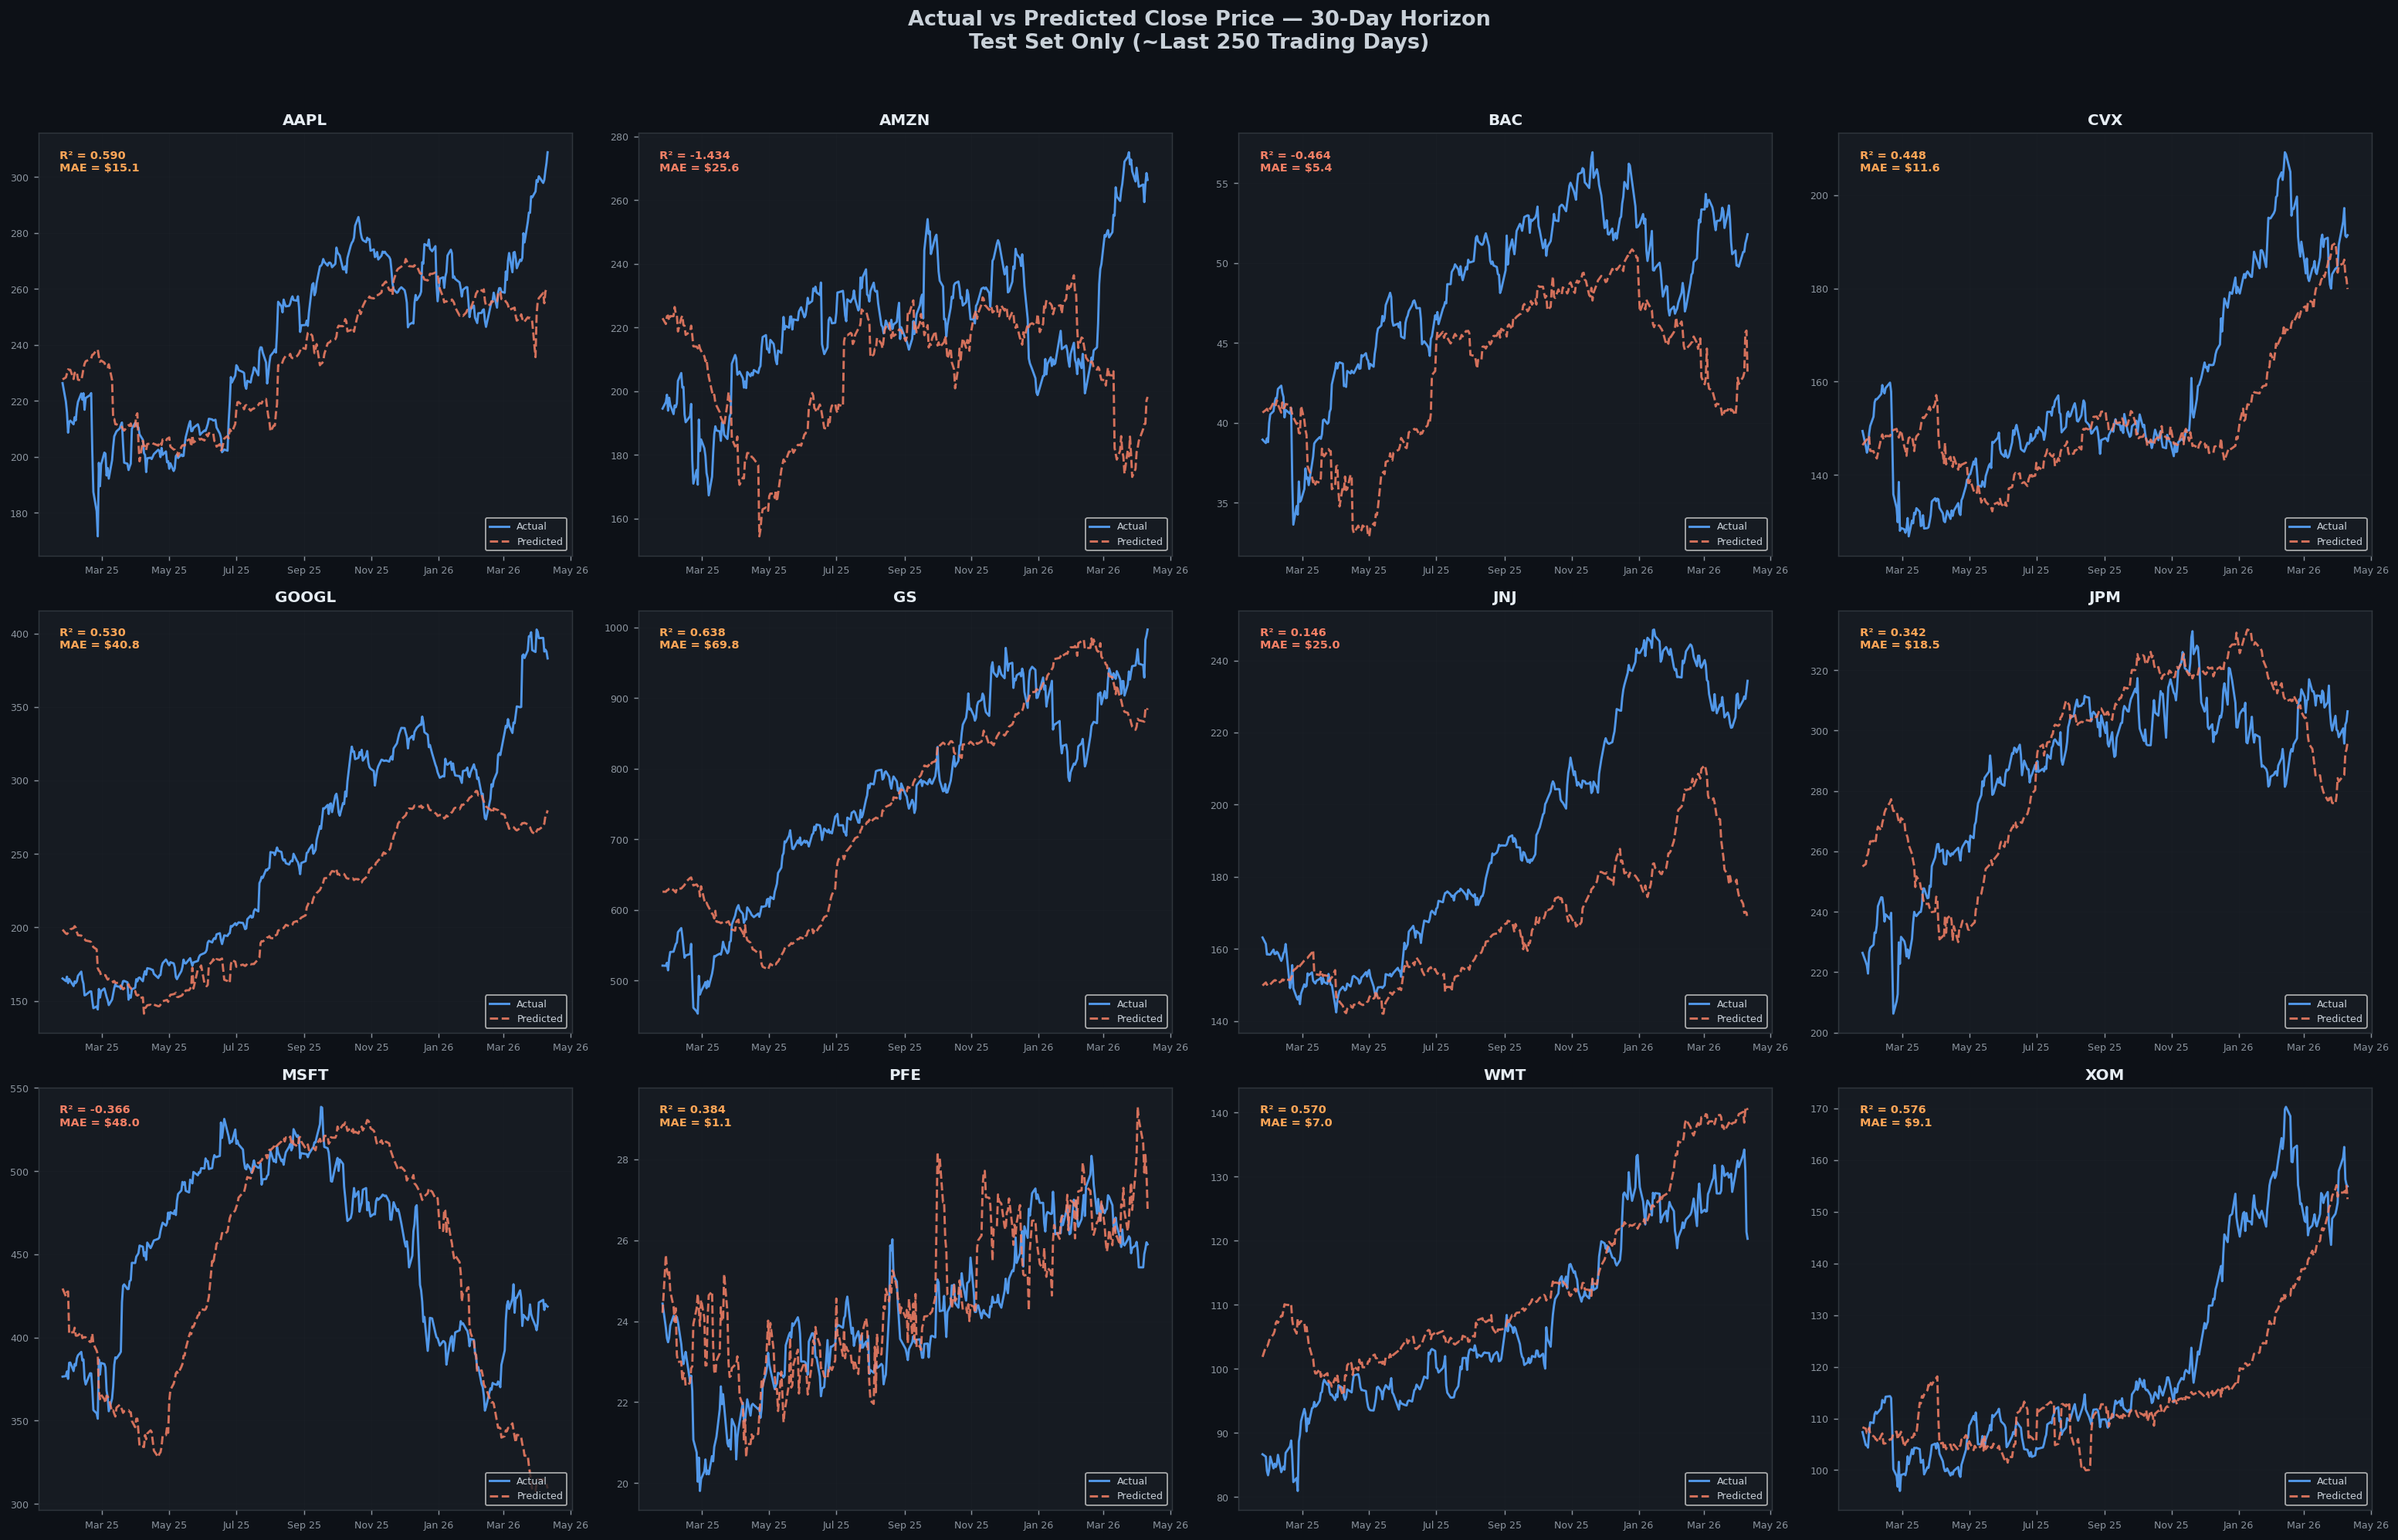

✓ Chart 6 saved: chart6_actual_vs_predicted.png


In [11]:
# CELL 7 — Actual vs Predicted Chart (Test Set)

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
fig.suptitle(
    "Actual vs Predicted Close Price — 30-Day Horizon\nTest Set Only (~Last 250 Trading Days)",
    fontsize=15, fontweight="bold", y=1.02
)

for ax, ticker in zip(axes.flatten(), all_tickers):

    result      = all_results[ticker]["short"]
    dates_test  = pd.to_datetime(result["d_test"])
    y_actual    = result["y_test"].values
    y_predicted = result["y_pred_test"]
    r2          = result["test_metrics"]["r2"]
    mae         = result["test_metrics"]["mae"]

    ax.plot(dates_test, y_actual,    color="#58a6ff", linewidth=1.6,
            label="Actual",    alpha=0.9)
    ax.plot(dates_test, y_predicted, color="#f78166", linewidth=1.6,
            label="Predicted", alpha=0.85, linestyle="--")

    color_r2 = "#3fb950" if r2 > 0.7 else "#ffa657" if r2 > 0.3 else "#f78166"
    ax.text(0.04, 0.96, f"R² = {r2:.3f}\nMAE = ${mae:.1f}",
            transform=ax.transAxes, fontsize=8,
            va="top", color=color_r2, fontweight="bold")

    ax.set_title(ticker, fontweight="bold", fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True, alpha=0.25)
    ax.set_facecolor("#161b22")
    ax.tick_params(labelsize=7)


plt.tight_layout()
plt.savefig(
    "../reports/chart6_actual_vs_predicted.png",
    dpi=150, bbox_inches="tight", facecolor="#0d1117"
)
plt.show()
print("✓ Chart 6 saved: chart6_actual_vs_predicted.png")

In [ ]:
# CELL 8 — Save Model, Metrics, and Forecasts

os.makedirs("../models", exist_ok=True)

# Save the AAPL short-horizon model as the representative model
model_bundle = {
    "model":        all_results["AAPL"]["short"]["model"],
    "scaler":       all_results["AAPL"]["short"]["scaler"],
    "feature_cols": all_results["AAPL"]["short"]["feature_cols"],
    "metrics":      metrics_df,
    "ticker":       "AAPL",
    "horizon_days": 30,
    "trained_at":   pd.Timestamp.now().isoformat(),
}

with open(f"../{MODEL_PATH}", "wb") as f:
    pickle.dump(model_bundle, f)

logger.info(f"Model saved: {MODEL_PATH}")
print(f"✓ Model saved: {MODEL_PATH}")

# Save forecasts to SQLite
conn = sqlite3.connect(f"../{DB_PATH}")

forecast_df.to_sql("fact_forecast", conn, if_exists="replace", index=False)
logger.info(f"fact_forecast loaded: {len(forecast_df):,} rows")

metrics_df.to_sql("ml_metrics", conn, if_exists="replace", index=False)
logger.info(f"ml_metrics loaded: {len(metrics_df):,} rows")

conn.commit()
conn.close()

# Save as CSV too
forecast_df.to_csv(f"../{PROCESSED_DATA_PATH}forecasts.csv", index=False)
metrics_df.to_csv(f"../{PROCESSED_DATA_PATH}ml_metrics.csv", index=False)

print(f"✓ fact_forecast saved: {len(forecast_df):,} rows")
print(f"✓ ml_metrics saved  : {len(metrics_df):,} rows")
print("\nNotebook 05 complete.")
print(f"Best test R² (AAPL, 30d): {all_results['AAPL']['short']['test_metrics']['r2']:.4f}")